In [32]:
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, Concatenate
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [33]:
image_dir = "/content/drive/MyDrive/Dataset/"   # main folder

img_height = 128
img_width = 128
batch_size = 16
epochs = 20

In [34]:
def load_all_good_images(base_dir, img_size=(128,128)):
    images = []

    # Loop through all type folders
    for folder in os.listdir(base_dir):
        type_path = os.path.join(base_dir, folder)

        if os.path.isdir(type_path):
            good_path = os.path.join(type_path, "train", "good")

            if os.path.exists(good_path):
                print(f"Loading from: {good_path}")

                for img_file in tqdm(os.listdir(good_path), desc=f"{folder}"):
                    img_path = os.path.join(good_path, img_file)

                    img = cv2.imread(img_path)
                    if img is None:
                        continue

                    img = cv2.resize(img, img_size)
                    img = img.astype(np.float32) / 255.0

                    images.append(img)

    return np.array(images)

In [35]:
X = load_all_good_images(image_dir, img_size=(img_height, img_width))

print("Total images loaded:", X.shape)

Loading from: /content/drive/MyDrive/Dataset/type5cam2/train/good


type5cam2: 100%|██████████| 181/181 [00:01<00:00, 97.86it/s] 


Loading from: /content/drive/MyDrive/Dataset/type9cam2/train/good


type9cam2: 100%|██████████| 721/721 [00:08<00:00, 89.77it/s] 


Loading from: /content/drive/MyDrive/Dataset/type3cam1/train/good


...

Loading from: /content/drive/MyDrive/Dataset/type10cam2/train/good


type10cam2: 100%|██████████| 717/717 [00:07<00:00, 93.49it/s] 


Loading from: /content/drive/MyDrive/Dataset/type8cam1/train/good


type8cam1: 100%|██████████| 711/711 [00:08<00:00, 80.67it/s] 


Total images loaded: (4391, 128, 128, 3)


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)

np.random.shuffle(X_train)

In [45]:
def build_unetpp(input_shape=(128, 128, 3)):
    inputs = Input(input_shape)

    # ======================
    # Encoder (same as U-Net)
    # ======================

    c1_0 = Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1_0 = Conv2D(32, 3, activation='relu', padding='same')(c1_0)
    p1 = MaxPooling2D()(c1_0)

    c2_0 = Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2_0 = Conv2D(64, 3, activation='relu', padding='same')(c2_0)
    p2 = MaxPooling2D()(c2_0)

    c3_0 = Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3_0 = Conv2D(128, 3, activation='relu', padding='same')(c3_0)
    p3 = MaxPooling2D()(c3_0)

    # Bottleneck
    b = Conv2D(256, 3, activation='relu', padding='same')(p3)
    b = Conv2D(256, 3, activation='relu', padding='same')(b)

    # ======================
    # Decoder (Nested)
    # ======================

    # Level 1
    u1_1 = Conv2DTranspose(128, 2, strides=2, padding='same')(b)
    u1_1 = Concatenate()([u1_1, c3_0])
    c3_1 = Conv2D(128, 3, activation='relu', padding='same')(u1_1)
    c3_1 = Conv2D(128, 3, activation='relu', padding='same')(c3_1)

    u2_1 = Conv2DTranspose(64, 2, strides=2, padding='same')(c3_0)
    u2_1 = Concatenate()([u2_1, c2_0])
    c2_1 = Conv2D(64, 3, activation='relu', padding='same')(u2_1)
    c2_1 = Conv2D(64, 3, activation='relu', padding='same')(c2_1)

    u3_1 = Conv2DTranspose(32, 2, strides=2, padding='same')(c2_0)
    u3_1 = Concatenate()([u3_1, c1_0])
    c1_1 = Conv2D(32, 3, activation='relu', padding='same')(u3_1)
    c1_1 = Conv2D(32, 3, activation='relu', padding='same')(c1_1)

    # Level 2 (Dense connections)
    u2_2 = Conv2DTranspose(64, 2, strides=2, padding='same')(c3_1)
    u2_2 = Concatenate()([u2_2, c2_0, c2_1])
    c2_2 = Conv2D(64, 3, activation='relu', padding='same')(u2_2)
    c2_2 = Conv2D(64, 3, activation='relu', padding='same')(c2_2)

    u3_2 = Conv2DTranspose(32, 2, strides=2, padding='same')(c2_1)
    u3_2 = Concatenate()([u3_2, c1_0, c1_1])
    c1_2 = Conv2D(32, 3, activation='relu', padding='same')(u3_2)
    c1_2 = Conv2D(32, 3, activation='relu', padding='same')(c1_2)

    # Level 3 (More dense)
    u3_3 = Conv2DTranspose(32, 2, strides=2, padding='same')(c2_2)
    u3_3 = Concatenate()([u3_3, c1_0, c1_1, c1_2])
    c1_3 = Conv2D(32, 3, activation='relu', padding='same')(u3_3)
    c1_3 = Conv2D(32, 3, activation='relu', padding='same')(c1_3)

    # ======================
    # Output
    # ======================
    outputs = Conv2D(3, 1, activation='sigmoid')(c1_3)

    return Model(inputs, outputs)

In [46]:
def ssim_loss(y_true, y_pred):
    return 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))

def combined_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    return mse + ssim_loss(y_true, y_pred)

model = build_unetpp((img_height, img_width, 3))

model.compile(
    optimizer=Adam(1e-4),
    loss=combined_loss
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 128, 128,  │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 128, 128,  │      9,248 │ conv2d_30[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 64, 64,    │          0 │ conv2d_31[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_32[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 32, 32,    │          0 │ conv2d_33[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_7[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 32, 32,    │    147,584 │ conv2d_34[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 16, 16,    │          0 │ conv2d_35[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 16, 16,    │    295,168 │ max_pooling2d_8[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 16, 16,    │    590,080 │ conv2d_36[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_6  │ (None, 32, 32,    │    131,200 │ conv2d_37[0][0]   │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ conv2d_35[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_7  │ (None, 64, 64,    │     32,832 │ conv2d_35[0][0]   │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 32, 32,    │    295,040 │ concatenate_6[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 64, 64,    │          0 │ conv2d_transpose

 Total params: 2,205,603 (8.41 MB)

 Trainable params: 2,205,603 (8.41 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
history = model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 74s 243ms/step - loss: 0.3174 - val_loss: 0.0434
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 34s 154ms/step - loss: 0.0277 - val_loss: 0.0216
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 34s 153ms/step - loss: 0.0169 - val_loss: 0.0160
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 34s 152ms/step - loss: 0.0132 - val_loss: 0.0116
Epoch 5/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 34s 153ms/step - loss: 0.0104 - val_loss: 0.0097
Epoch 6/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 34s 154ms/step - loss: 0.0088 - val_loss: 0.0082
Epoch 7/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 34s 153ms/step - loss: 0.0078 - val_loss: 0.0073
Epoch 8/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 34s 152ms/step - loss: 0.0067 - val_loss: 0.0064
Epoch 9/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 34s 153ms/step - loss: 0.0060 - val_loss: 0.0057
Epoch 10/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 34s 153ms/step - loss: 0.0054 - val_loss: 0.0051
Epoch 11/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 34s 153ms/step - loss: 0.0049 - val_loss: 0.0051
Epoch 12/20
220/220

In [48]:
model.save("/content/drive/MyDrive/unetpp_model.h5")

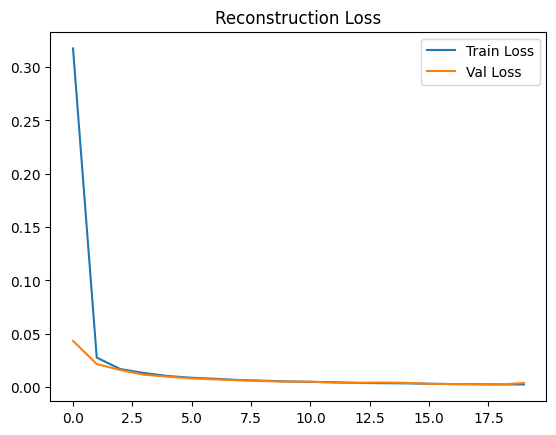

In [49]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Reconstruction Loss')
plt.legend()
plt.show()

In [50]:
val_errors = []

crop = 10   # ignore border pixels

# Iterate directly over the validation image data from X_val
# X_val already contains normalized images
for img_data_single in X_val[:100]:
    img_input = np.expand_dims(img_data_single, axis=0)

    recon = model.predict(img_input)[0]

    # ✅ Pixel-wise error
    error_map = np.mean((img_data_single - recon) ** 2, axis=2) # Compare original image data with reconstruction

    # ✅ Smooth error (reduce noise)
    error_map = cv2.GaussianBlur(error_map, (5,5), 0)

    # ✅ Remove borders
    h, w = error_map.shape
    cropped_error = error_map[crop:h-crop, crop:w-crop]

    # ✅ Top-K scoring (more robust)
    flat = cropped_error.flatten()
    score = np.mean(np.sort(flat)[-300:])   # top 300 pixels

    val_errors.append(score)

# ✅ Final threshold
threshold = np.mean(val_errors) + 2 * np.std(val_errors)

print("Threshold:", threshold)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━

Saving 8277.png to 8277.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


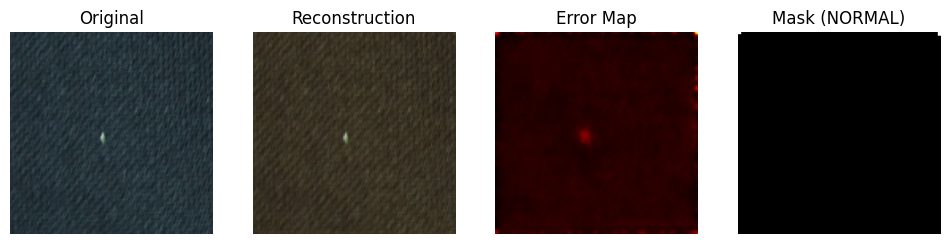

Score: 0.0003491578044741657
Prediction: NORMAL


In [53]:
from google.colab import files

uploaded = files.upload()

crop = 10   # ignore edges

for filename in uploaded.keys():
    img = cv2.imread(filename)
    original_size = img.shape[:2]

    img_resized = cv2.resize(img, (img_width, img_height))
    img_norm = img_resized / 255.0
    img_input = np.expand_dims(img_norm, axis=0)

    recon = model.predict(img_input)[0]

    # ✅ Pixel-wise MSE error
    error_map = np.mean((img_norm - recon) ** 2, axis=2)

    # ✅ Smooth error (removes texture noise)
    error_map = cv2.GaussianBlur(error_map, (5,5), 0)

    # ✅ Remove borders
    h, w = error_map.shape
    cropped_error = error_map[crop:h-crop, crop:w-crop]

    # ✅ Resize for visualization
    error_map_resized = cv2.resize(error_map, (original_size[1], original_size[0]))

    # ✅ Pixel threshold (ONLY on cropped region)
    #pixel_threshold = np.percentile(cropped_error, 99)

    # ✅ Mask creation

    # ✅ Normalize error map (0 → 1)
    norm_error = (error_map - error_map.min()) / (error_map.max() - error_map.min() + 1e-8)

    # ✅ Threshold based on intensity (like red region)
    pixel_threshold = 0.2   # you can tune: 0.3–0.6

    mask = (norm_error > pixel_threshold).astype(np.uint8) * 255
    # mask = np.zeros_like(error_map, dtype=np.uint8)
    # mask[crop:h-crop, crop:w-crop] = (cropped_error > pixel_threshold).astype(np.uint8)

    # ✅ Resize mask
    # mask = cv2.resize(mask, (original_size[1], original_size[0])) * 255

    # 🔥 Morphological cleaning
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # ✅ Better scoring (Top-K on cropped region)
    flat = cropped_error.flatten()
    score = np.mean(np.sort(flat)[-5:])

    # ✅ Classification
    label = "ANOMALY" if score > threshold else "NORMAL"

    # 🔥 Normalize error map for display
    vis_error = (error_map - error_map.min()) / (error_map.max() - error_map.min() + 1e-8)

    # Plot
    plt.figure(figsize=(12,4))

    plt.subplot(1,4,1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(recon.astype(np.float32)) # Cast recon to float32
    plt.title("Reconstruction")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(vis_error.astype(np.float32), cmap='hot') # Cast vis_error to float32
    plt.title("Error Map")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(mask, cmap='gray')
    plt.title(f"Mask ({label})")
    plt.axis("off")

    plt.show()

    print("Score:", score)
    print("Prediction:", label)
